# $C^1$ Rational Fractal Interpolation Function

We define the Iterated Function System

$$
w_n(x,y)
=
\begin{pmatrix}
L_n(x) \\
F_n(x,y)
\end{pmatrix}
$$

where

$$
L_n(x)=a_nx+b_n
$$

and

$$
F_n(x,y)
=
\alpha_n y + R_n(x)
$$

The rational function is

$$
R_n(x)
=
\frac{P_n(x)}{Q_n(x)}
$$

with

$$
\theta
=
\frac{x-x_1}{x_N-x_1}
$$

The denominator is

$$
Q_n(x)
=
(1-\theta)^2v_n
+
2u_nv_n\theta(1-\theta)
+
\theta^2u_n
$$

The numerator is cubic:

$$
P_n(x)
=
A_n(1-\theta)^3
+
B_n\theta(1-\theta)^2
+
C_n\theta^2(1-\theta)
+
D_n\theta^3
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1 : Input interpolation data

Input:

$$
(x_i,y_i)
$$

together with:

- scaling factors

$$
\alpha_i
$$

- shape parameters

$$
u_i,v_i
$$

- derivative values

$$
d_i
$$

In [2]:
# Interpolation points

x = np.array([0, 1, 2, 3, 4], dtype=float)
y = np.array([0, 2, 1, 3, 0], dtype=float)

# Vertical scaling factors
alpha = np.array([0.2, -0.3, 0.25, 0.2])

# Shape parameters
u = np.array([1.5, 2.0, 1.8, 2.2])
v = np.array([1.2, 1.7, 1.5, 2.0])

# Derivative values
d = np.array([1.0, -0.5, 0.8, -0.2, 1.2])

# Number of maps
N = len(x) - 1

# Step 2 : Compute affine coefficients

The horizontal maps satisfy

$$
L_n(x_1)=x_n
$$

and

$$
L_n(x_N)=x_{n+1}
$$

Hence,

$$
a_n
=
\frac{
x_{n+1}-x_n
}{
x_N-x_1
}
$$

and

$$
b_n
=
\frac{
x_Nx_n-x_1x_{n+1}
}{
x_N-x_1
}
$$

In [3]:
x1 = x[0]
xN = x[-1]

y1 = y[0]
yN = y[-1]

h = np.diff(x)

a = np.zeros(N)
b = np.zeros(N)

for n in range(N):

    a[n] = (x[n+1] - x[n]) / (xN - x1)

    b[n] = (xN*x[n]- x1*x[n+1]) / (xN - x1)

# Step 3 : Compute coefficients of numerator

The coefficients are

$$
A_n
=
(f_n-\alpha_nf_1)v_n
$$

$$
D_n
=
(f_{n+1}-\alpha_nf_N)u_n
$$

$$
B_n
=
(2u_nv_n+v_n)f_n
+
v_n h_n d_n
-
\alpha_n
\left[
(2u_nv_n+v_n)f_1
+
v_n(x_N-x_1)d_1
\right]
$$

$$
C_n
=
(2u_nv_n+u_n)f_{n+1}
-
u_n h_n d_{n+1}
-
\alpha_n
\left[
(2u_nv_n+u_n)f_N
-
u_n(x_N-x_1)d_N
\right]
$$

In [4]:
A = np.zeros(N)
B = np.zeros(N)
C = np.zeros(N)
D = np.zeros(N)

for n in range(N):

    A[n] = (y[n] - alpha[n]*y1) * v[n]

    D[n] = (y[n+1] - alpha[n]*yN ) * u[n]

    B[n] = ((2*u[n]*v[n] + v[n])*y[n] + v[n]*h[n]*d[n] - 
            alpha[n]*( (2*u[n]*v[n] + v[n])*y1 + v[n]*(xN - x1)*d[0]))

    C[n] = (
        (2*u[n]*v[n] + u[n])*y[n+1] - u[n]*h[n]*d[n+1]
        - alpha[n]*((2*u[n]*v[n] + u[n])*yN - u[n]*(xN - x1)*d[-1]))

# Step 4 : Define the rational function

The denominator is

$$
Q_n(x)
=
(1-\theta)^2v_n
+
2u_nv_n\theta(1-\theta)
+
\theta^2u_n
$$

The numerator is

$$
P_n(x)
=
A_n(1-\theta)^3
+
B_n\theta(1-\theta)^2
+
C_n\theta^2(1-\theta)
+
D_n\theta^3
$$

Hence,

$$
R_n(x)
=
\frac{
P_n(x)
}{
Q_n(x)
}
$$

In [5]:
def R(n, x_value):

    theta = ( x_value - x1 ) / ( xN - x1 )

    numerator = ( A[n]*(1-theta)**3
                    +
                    B[n]*theta*(1-theta)**2
                    +
                    C[n]*theta**2*(1-theta)
                    +
                    D[n]*theta**3
                )

    denominator = ((1-theta)**2 * v[n]
                    +
                    2*u[n]*v[n]*theta*(1-theta)
                    +
                    theta**2 * u[n]
                   )

    return numerator / denominator

# Step 5 : Define the IFS maps

The transformations are

$$
w_n(x,y)
=
\begin{pmatrix}
L_n(x) \\
F_n(x,y)
\end{pmatrix}
$$

where

$$
F_n(x,y)
=
\alpha_n y + R_n(x)
$$

In [6]:
def w(n, point):

    x_current, y_current = point

    # Horizontal transformation
    new_x = ( a[n]*x_current + b[n])

    # Vertical transformation
    new_y = (alpha[n]*y_current + R(n, x_current))

    return np.array([new_x, new_y])

# Step 6 : Random Iteration Algorithm

Generate a stochastic orbit:

$$
(X_{k+1},Y_{k+1})
=
w_{i_k}(X_k,Y_k)
$$

where

$$
i_k
\in
\{1,2,\dots,N-1\}
$$

is randomly selected.

In [7]:
num_iterations = 200000

points = np.zeros((num_iterations, 2))

current_point = np.array([x1, y1])

for k in range(num_iterations):

    # Random map selection
    n = np.random.randint(0, N)

    # Apply transformation
    current_point = w(n, current_point)

    points[k] = current_point

# Step 7 : Plot random iteration attractor

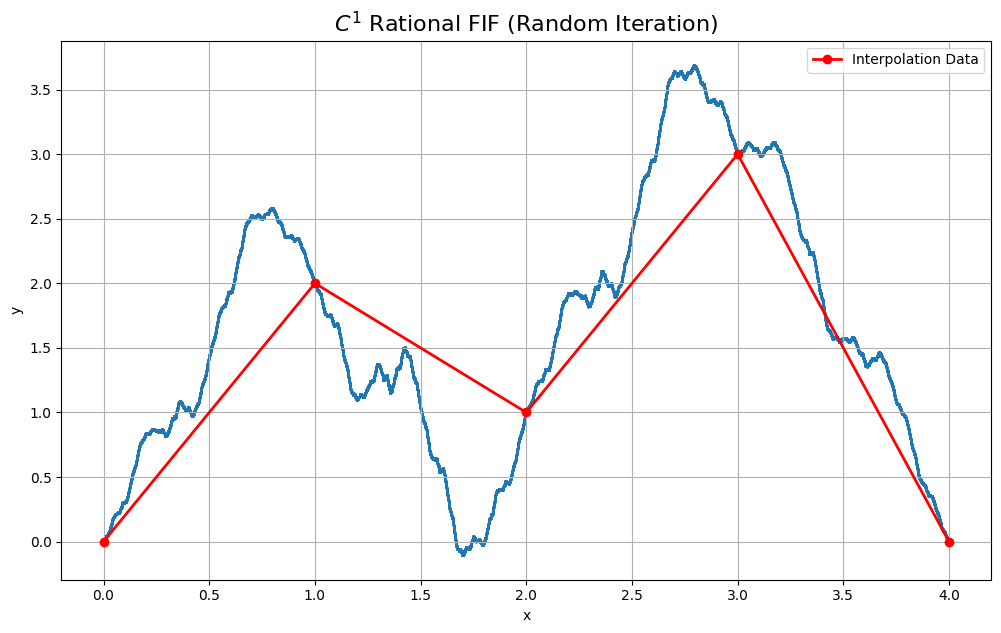

In [8]:
plt.figure(figsize=(12,7))

plt.scatter(
    points[:,0],
    points[:,1],
    s=0.1
)

plt.plot(
    x,
    y,
    'ro-',
    linewidth=2,
    label='Interpolation Data'
)

plt.title(
    "$C^1$ Rational FIF (Random Iteration)",
    fontsize=16
)

plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)
plt.legend()

plt.show()

# Step 8 : Deterministic Algorithm

The deterministic iteration evolves sets:

$$
A_{k+1}
=
\bigcup_{n=1}^{N-1}
w_n(A_k)
$$

Start with the interpolation data as the initial approximation.

In [9]:
current_points = np.column_stack((x, y))

deterministic_iterations = 7

# Step 9 : Apply deterministic iterations

At each iteration:

1. Take every current point
2. Apply every affine map
3. Collect all transformed points
4. Form the next approximation

In [10]:
for iteration in range(deterministic_iterations):

    new_points = []

    for n in range(N):
        for point in current_points:
            transformed_point = w(n, point)
            new_points.append(transformed_point)

    current_points = np.array(new_points)
    print( f"Iteration {iteration+1}: " f"{len(current_points)} points")

Iteration 1: 20 points
Iteration 2: 80 points
Iteration 3: 320 points
Iteration 4: 1280 points
Iteration 5: 5120 points
Iteration 6: 20480 points
Iteration 7: 81920 points


# Step 10 : Plot deterministic attractor

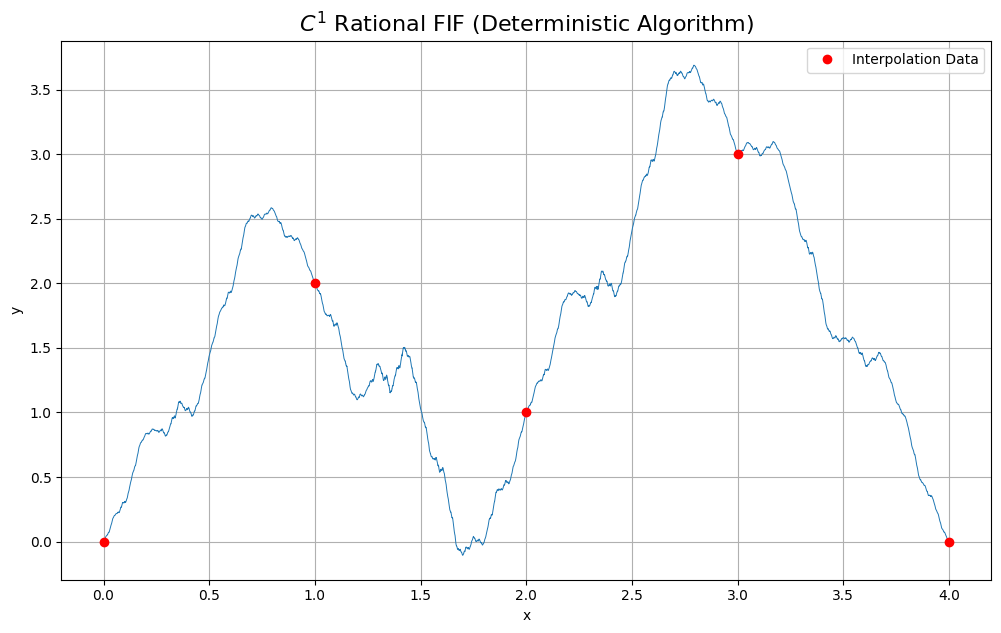

In [11]:
sorted_indices = np.argsort(current_points[:,0])

sorted_points = current_points[sorted_indices]

plt.figure(figsize=(12,7))

plt.plot(
    sorted_points[:,0],
    sorted_points[:,1],
    linewidth=0.7
)

plt.plot(
    x,
    y,
    'ro',
    markersize=6,
    label='Interpolation Data'
)

plt.title(
    "$C^1$ Rational FIF (Deterministic Algorithm)",
    fontsize=16
)

plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)
plt.legend()
plt.show()